# <FONT COLOR="Red">Comparaison SVM / Arbre / Forêt / Boosting</font>

Ce notebook reprend l'esprit des notebooks déjà commencés dans le dossier `analyses_python`, avec un code volontairement simple et lisible.

L'objectif est double :
- prédire `Heart_Disease_Risk` avec des modèles de classification non linéaires,
- prédire `Cholesterol_LDL` avec des modèles de régression non linéaires.

Les modèles comparés sont :
- `SVM` pour la classification et `SVR` pour la régression,
- un arbre de décision optimisé par validation croisée,
- une forêt aléatoire,
- un modèle de boosting.

On garde les idées simples de tes notebooks :
- `get_dummies()` pour les variables qualitatives,
- `train_test_split()` avec `20%` de test,
- `StandardScaler()` seulement pour `SVM/SVR`,
- `GridSearchCV()` pour régler les hyperparamètres.


## 1. Librairies

On utilise uniquement `pandas`, `matplotlib` et `scikit-learn`, comme dans les autres notebooks.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)


## 2. Chargement des données

Le jeu de données utilisé est bien celui fourni dans le repo.


In [2]:
path = '/home/gugubre/Cours/ML_Projet/ML-project/divers/healthcare_synthetic_data.csv'
data = pd.read_csv(path)

print('Dimensions :', data.shape)
data.head()


Dimensions : (15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


## 3. Préparation des données

On reprend la logique déjà utilisée dans `kNN_SVM_gus.ipynb` :
- suppression de `Patient_ID`,
- conversion des variables qualitatives,
- création de variables indicatrices avec `get_dummies`.

Remarques importantes :
- pour la **classification**, on prédit `Heart_Disease_Risk` à partir de toutes les autres variables,
- pour la **régression**, on prédit `Cholesterol_LDL` à partir de toutes les autres variables **sauf** `Heart_Disease_Risk`.


In [3]:
data = data.drop('Patient_ID', axis=1)

data['Gender'] = pd.Categorical(data['Gender'], ordered=False)
data['Smoking_Status'] = pd.Categorical(data['Smoking_Status'], ordered=False)
data['Alcohol_Consumption'] = pd.Categorical(data['Alcohol_Consumption'], ordered=False)
data['Physical_Activity_Level'] = pd.Categorical(data['Physical_Activity_Level'], ordered=False)
data['Family_History'] = pd.Categorical(data['Family_History'], ordered=False)
data['Heart_Disease_Risk'] = pd.Categorical(data['Heart_Disease_Risk'], ordered=False)

data.dtypes


Age                           int64
Gender                     category
Height_cm                   float64
Weight_kg                   float64
BMI                         float64
Systolic_BP                   int64
Diastolic_BP                  int64
Cholesterol_Total             int64
Cholesterol_LDL               int64
Cholesterol_HDL               int64
Fasting_Blood_Sugar           int64
Smoking_Status             category
Alcohol_Consumption        category
Physical_Activity_Level    category
Family_History             category
Stress_Level                  int64
Sleep_Hours                   int64
Heart_Disease_Risk         category
dtype: object

In [4]:
# Variables explicatives pour la classification
dataDum_class = pd.get_dummies(
    data[['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History']],
    drop_first=True,
)

dataQuant_class = data[
    [
        'Age',
        'Height_cm',
        'Weight_kg',
        'BMI',
        'Systolic_BP',
        'Diastolic_BP',
        'Cholesterol_Total',
        'Cholesterol_LDL',
        'Cholesterol_HDL',
        'Fasting_Blood_Sugar',
        'Stress_Level',
        'Sleep_Hours',
    ]
]

dataC_class = pd.concat([dataDum_class, dataQuant_class], axis=1)
Y_class = data['Heart_Disease_Risk'].astype(int)

print('Dimensions matrice classification :', dataC_class.shape)
dataC_class.head()


Dimensions matrice classification : (15000, 20)


,Gender_1,Smoking_Status_1,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_1,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
0,False,False,True,False,False,False,True,False,60,146.9,51.3,23.8,140,89,217,151,52,83,1,8
1,False,False,False,False,True,False,False,False,53,161.8,76.6,29.3,128,81,203,119,38,116,7,9
2,True,False,False,False,False,False,False,False,62,174.7,92.4,30.3,141,100,173,124,45,90,1,7
3,True,False,False,False,True,False,False,False,73,173.3,68.9,22.9,136,96,193,117,45,81,2,7
4,True,False,True,False,False,True,False,False,52,178.6,79.8,25.0,122,80,236,153,41,79,2,6


In [5]:
# Variables explicatives pour la régression de Cholesterol_LDL
data_reg = pd.read_csv(path)
data_reg = data_reg.drop(columns=['Patient_ID', 'Heart_Disease_Risk', 'Cholesterol_LDL'])

dataC_reg = pd.get_dummies(
    data_reg,
    columns=['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History'],
    drop_first=True,
)

Y_reg = pd.read_csv(path)['Cholesterol_LDL']

print('Dimensions matrice regression :', dataC_reg.shape)
dataC_reg.head()


Dimensions matrice regression : (15000, 19)


,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours,Gender_1,Smoking_Status_1,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_1
0,60,146.9,51.3,23.8,140,89,217,52,83,1,8,False,False,True,False,False,False,True,False
1,53,161.8,76.6,29.3,128,81,203,38,116,7,9,False,False,False,False,True,False,False,False
2,62,174.7,92.4,30.3,141,100,173,45,90,1,7,True,False,False,False,False,False,False,False
3,73,173.3,68.9,22.9,136,96,193,45,81,2,7,True,False,False,False,True,False,False,False
4,52,178.6,79.8,25.0,122,80,236,41,79,2,6,True,False,True,False,False,True,False,False


## 4. Séparation apprentissage / test

Comme demandé dans l'énoncé, on prend `20%` des données pour le test.

Pourquoi cette étape est nécessaire ?

Parce qu'un modèle peut très bien s'ajuster aux données d'apprentissage sans forcément bien généraliser.  
Le test permet donc d'obtenir une estimation plus honnête des performances sur de nouvelles observations.


In [6]:
# Classification
X_train_class, X_test_class, Y_train_class, Y_test_class = train_test_split(
    dataC_class,
    Y_class,
    test_size=0.2,
    random_state=42,
    stratify=Y_class,
)

# Regression
X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    dataC_reg,
    Y_reg,
    test_size=0.2,
    random_state=42,
)

print('Classification - train :', X_train_class.shape, 'test :', X_test_class.shape)
print('Regression     - train :', X_train_reg.shape, 'test :', X_test_reg.shape)


Classification - train : (12000, 20) test : (3000, 20)
Regression     - train : (12000, 19) test : (3000, 19)


## 5. Standardisation pour SVM / SVR

Comme dans tes notebooks précédents, on standardise les variables uniquement pour les méthodes à base de marges (`SVM/SVR`).

Pour les arbres, forêts et boosting, ce n'est pas nécessaire.


In [7]:
scaler_class = StandardScaler()
Xr_train_class = scaler_class.fit_transform(X_train_class)
Xr_test_class = scaler_class.transform(X_test_class)

scaler_reg = StandardScaler()
Xr_train_reg = scaler_reg.fit_transform(X_train_reg)
Xr_test_reg = scaler_reg.transform(X_test_reg)


## 6. Fonctions utiles

On prépare deux petites fonctions pour éviter de répéter exactement le même code pour tous les modèles.


In [8]:
def resume_classification(modele, parametres, X_train, Y_train, X_test, Y_test, nom):
    grid = GridSearchCV(modele, parametres, cv=5, n_jobs=-1, scoring='accuracy')
    grid.fit(X_train, Y_train)
    y_pred = grid.predict(X_test)

    resultat = pd.DataFrame({
        'Modele': [nom],
        'Best params': [str(grid.best_params_)],
        'CV accuracy': [grid.best_score_],
        'Test accuracy': [accuracy_score(Y_test, y_pred)],
        'Test precision': [precision_score(Y_test, y_pred)],
        'Test recall': [recall_score(Y_test, y_pred)],
        'Test F1': [f1_score(Y_test, y_pred)],
    })

    return grid, y_pred, resultat


def resume_regression(modele, parametres, X_train, Y_train, X_test, Y_test, nom):
    grid = GridSearchCV(modele, parametres, cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error')
    grid.fit(X_train, Y_train)
    y_pred = grid.predict(X_test)

    rmse = mean_squared_error(Y_test, y_pred) ** 0.5

    resultat = pd.DataFrame({
        'Modele': [nom],
        'Best params': [str(grid.best_params_)],
        'CV RMSE': [-grid.best_score_],
        'Test RMSE': [rmse],
        'Test MAE': [mean_absolute_error(Y_test, y_pred)],
        'Test R2': [r2_score(Y_test, y_pred)],
    })

    return grid, y_pred, resultat


# Partie A. Prédiction de `Heart_Disease_Risk`

On compare ici quatre méthodes de classification non linéaires.


## 7. SVM pour `Heart_Disease_Risk`

### Justification du choix

On choisit ici un noyau `rbf` :
- il est plus souple qu'un noyau linéaire,
- il permet de modéliser des frontières de décision non linéaires,
- c'est en général un bon choix de départ lorsqu'on ne veut pas trop complexifier.

### Hyperparamètres réglés

- `C` : contrôle la pénalisation des erreurs,
- `gamma` : contrôle l'influence locale des observations,
- `kernel='rbf'` : noyau gaussien.


In [9]:
param_svm_class = [{'C': [0.5, 1, 2], 'gamma': ['scale', 0.05], 'kernel': ['rbf']}]

svm_class, y_pred_svm_class, res_svm_class = resume_classification(
    SVC(),
    param_svm_class,
    Xr_train_class,
    Y_train_class,
    Xr_test_class,
    Y_test_class,
    'SVM (rbf)',
)

print("Meilleur score CV =", svm_class.best_score_)
print("Meilleurs paramètres =", svm_class.best_params_)
res_svm_class


Meilleur score CV = 0.7311666666666667
Meilleurs paramètres = {'C': 0.5, 'gamma': 0.05, 'kernel': 'rbf'}


,Modele,Best params,CV accuracy,Test accuracy,Test precision,Test recall,Test F1
0,SVM (rbf),"{'C': 0.5, 'gamma': 0.05, 'kernel': 'rbf'}",0.731167,0.729333,0.720641,0.619266,0.666118


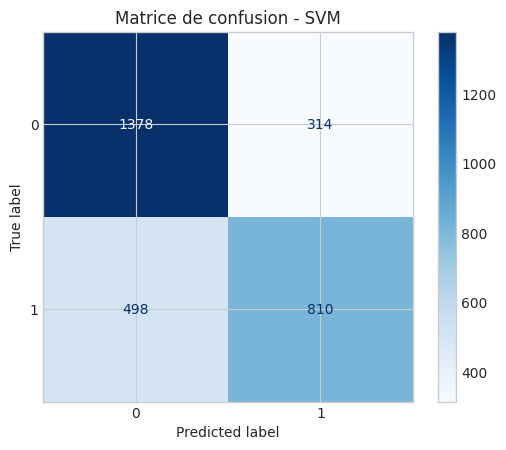

In [10]:
ConfusionMatrixDisplay.from_predictions(Y_test_class, y_pred_svm_class, cmap='Blues')
plt.title('Matrice de confusion - SVM')
plt.show()


## 8. Arbre de décision pour `Heart_Disease_Risk`

### Justification du choix

L'arbre est intéressant car :
- il est simple à interpréter,
- il capture des effets non linéaires et des interactions,
- il fournit une première lecture claire des variables les plus utiles.

### Hyperparamètres réglés

- `max_depth` : profondeur maximale de l'arbre,
- `min_samples_leaf` : nombre minimal d'observations par feuille,
- `ccp_alpha` : paramètre d'élagage pour éviter un arbre trop complexe.


In [11]:
param_tree_class = [{'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 5, 10], 'ccp_alpha': [0, 0.001]}]

tree_class, y_pred_tree_class, res_tree_class = resume_classification(
    DecisionTreeClassifier(random_state=42),
    param_tree_class,
    X_train_class,
    Y_train_class,
    X_test_class,
    Y_test_class,
    'Arbre de decision',
)

print("Meilleur score CV =", tree_class.best_score_)
print("Meilleurs paramètres =", tree_class.best_params_)
res_tree_class


Meilleur score CV = 0.7070833333333333
Meilleurs paramètres = {'ccp_alpha': 0, 'max_depth': 5, 'min_samples_leaf': 10}


,Modele,Best params,CV accuracy,Test accuracy,Test precision,Test recall,Test F1
0,Arbre de decision,"{'ccp_alpha': 0, 'max_depth': 5, 'min_samples_...",0.707083,0.708,0.707294,0.563456,0.627234


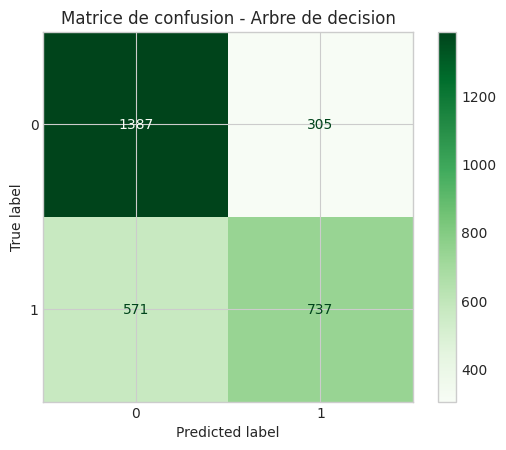

In [12]:
ConfusionMatrixDisplay.from_predictions(Y_test_class, y_pred_tree_class, cmap='Greens')
plt.title('Matrice de confusion - Arbre de decision')
plt.show()


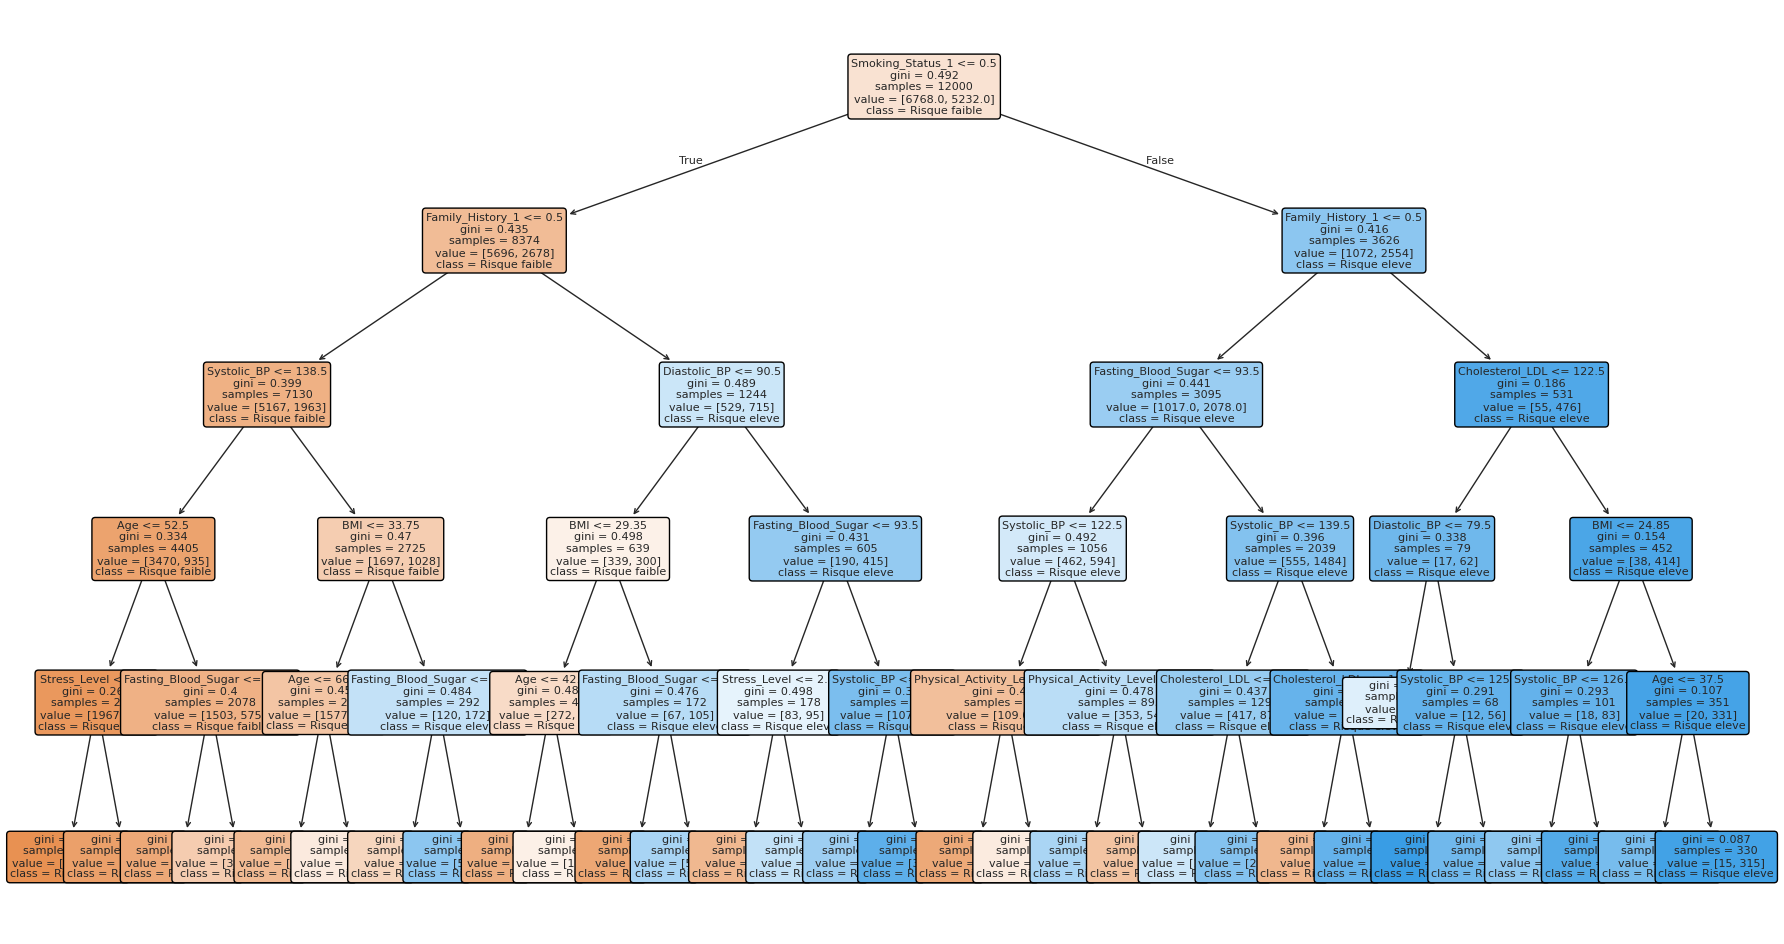

In [13]:
best_tree_class = tree_class.best_estimator_

plt.figure(figsize=(22, 12))
plot_tree(
    best_tree_class,
    feature_names=X_train_class.columns.tolist(),
    class_names=['Risque faible', 'Risque eleve'],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.show()


## 9. Forêt aléatoire pour `Heart_Disease_Risk`

### Justification du choix

La forêt aléatoire corrige une partie de l'instabilité d'un arbre seul :
- elle agrège beaucoup d'arbres,
- elle réduit la variance,
- elle donne souvent de meilleures performances prédictives.

### Hyperparamètres réglés

- `n_estimators` : nombre d'arbres,
- `max_features` : nombre de variables tirées aléatoirement à chaque split,
- `max_depth` : profondeur maximale,
- `min_samples_leaf` : taille minimale d'une feuille.


In [14]:
param_rf_class = [{
    'n_estimators': [200],
    'max_features': ['sqrt', 5],
    'max_depth': [None, 8, 12],
    'min_samples_leaf': [1, 5],
}]

rf_class, y_pred_rf_class, res_rf_class = resume_classification(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_rf_class,
    X_train_class,
    Y_train_class,
    X_test_class,
    Y_test_class,
    'Foret aleatoire',
)

print("Meilleur score CV =", rf_class.best_score_)
print("Meilleurs paramètres =", rf_class.best_params_)
res_rf_class


Meilleur score CV = 0.7283333333333333
Meilleurs paramètres = {'max_depth': None, 'max_features': 5, 'min_samples_leaf': 5, 'n_estimators': 200}


,Modele,Best params,CV accuracy,Test accuracy,Test precision,Test recall,Test F1
0,Foret aleatoire,"{'max_depth': None, 'max_features': 5, 'min_sa...",0.728333,0.727,0.712424,0.626911,0.666938


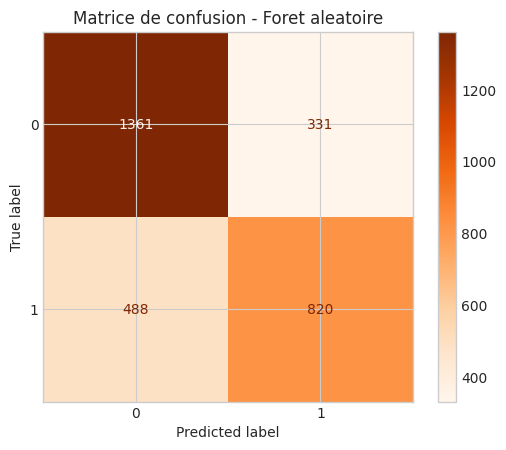

In [15]:
ConfusionMatrixDisplay.from_predictions(Y_test_class, y_pred_rf_class, cmap='Oranges')
plt.title('Matrice de confusion - Foret aleatoire')
plt.show()


In [16]:
importances_rf_class = pd.Series(
    rf_class.best_estimator_.feature_importances_,
    index=X_train_class.columns,
).sort_values(ascending=False)

importances_rf_class.head(10)


Smoking_Status_1       0.197397
Fasting_Blood_Sugar    0.077402
Systolic_BP            0.075972
Age                    0.071811
BMI                    0.064981
Weight_kg              0.063055
Cholesterol_Total      0.059043
Cholesterol_LDL        0.058247
Family_History_1       0.058106
Height_cm              0.057070
dtype: float64

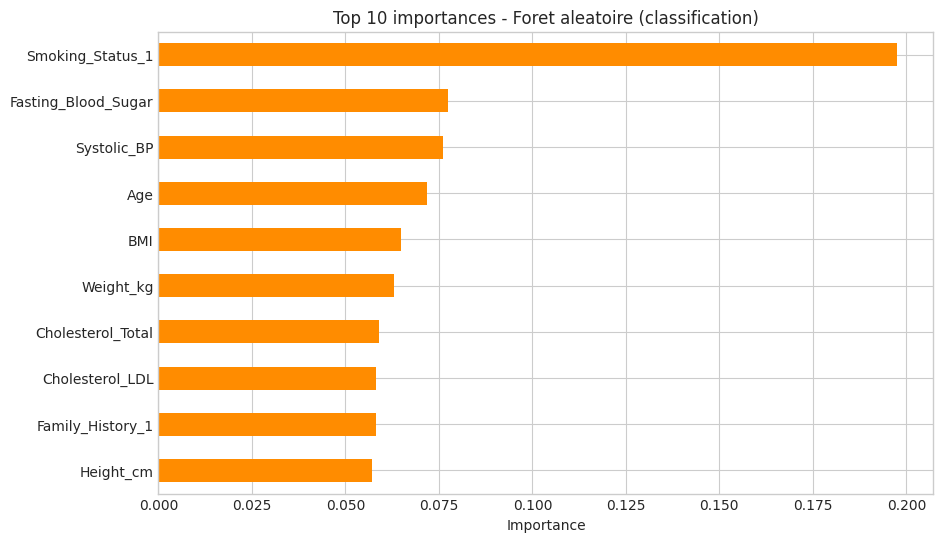

In [17]:
plt.figure(figsize=(10, 6))
importances_rf_class.head(10).sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 10 importances - Foret aleatoire (classification)')
plt.xlabel('Importance')
plt.show()


## 10. Boosting pour `Heart_Disease_Risk`

### Justification du choix

Le boosting construit les arbres successivement pour corriger les erreurs précédentes.  
Sur ce type de données tabulaires, c'est souvent une méthode très performante sans trop compliquer le code.

### Hyperparamètres réglés

- `n_estimators` : nombre d'arbres,
- `learning_rate` : vitesse d'apprentissage,
- `max_depth` : profondeur des arbres faibles.


In [18]:
param_gb_class = [{'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [1, 2, 3]}]

gb_class, y_pred_gb_class, res_gb_class = resume_classification(
    GradientBoostingClassifier(random_state=42),
    param_gb_class,
    X_train_class,
    Y_train_class,
    X_test_class,
    Y_test_class,
    'Boosting',
)

print("Meilleur score CV =", gb_class.best_score_)
print("Meilleurs paramètres =", gb_class.best_params_)
res_gb_class


Meilleur score CV = 0.7355833333333333
Meilleurs paramètres = {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}


,Modele,Best params,CV accuracy,Test accuracy,Test precision,Test recall,Test F1
0,Boosting,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.735583,0.727,0.708085,0.636086,0.670157


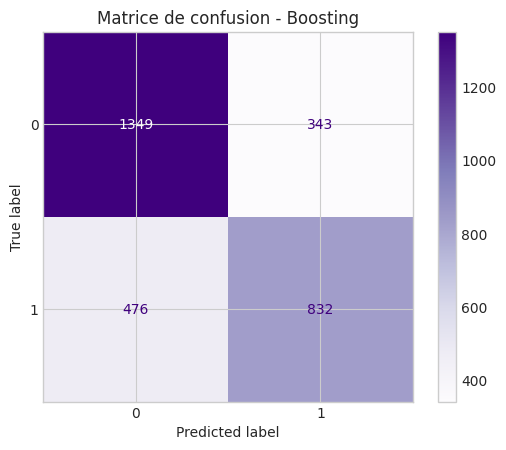

In [19]:
ConfusionMatrixDisplay.from_predictions(Y_test_class, y_pred_gb_class, cmap='Purples')
plt.title('Matrice de confusion - Boosting')
plt.show()


## 11. Tableau récapitulatif en classification

On rassemble maintenant les performances test des quatre méthodes.


In [20]:
resume_class = pd.concat(
    [res_svm_class, res_tree_class, res_rf_class, res_gb_class],
    ignore_index=True,
)

resume_class = resume_class.sort_values('Test accuracy', ascending=False)
resume_class


,Modele,Best params,CV accuracy,Test accuracy,Test precision,Test recall,Test F1
0,SVM (rbf),"{'C': 0.5, 'gamma': 0.05, 'kernel': 'rbf'}",0.731167,0.729333,0.720641,0.619266,0.666118
2,Foret aleatoire,"{'max_depth': None, 'max_features': 5, 'min_sa...",0.728333,0.727000,0.712424,0.626911,0.666938
3,Boosting,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.735583,0.727000,0.708085,0.636086,0.670157
1,Arbre de decision,"{'ccp_alpha': 0, 'max_depth': 5, 'min_samples_...",0.707083,0.708000,0.707294,0.563456,0.627234


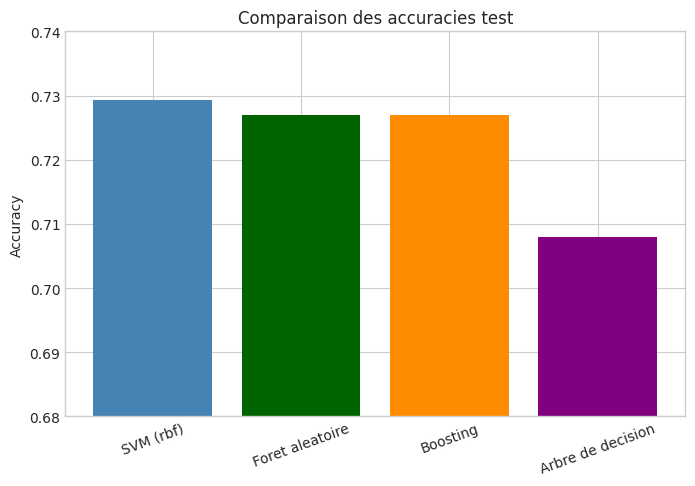

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(resume_class['Modele'], resume_class['Test accuracy'], color=['steelblue', 'darkgreen', 'darkorange', 'purple'])
plt.ylim(0.68, 0.74)
plt.title('Comparaison des accuracies test')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.show()


## 12. Interprétation des résultats en classification

Avec `random_state=42`, on obtient les résultats suivants :

- `SVM (rbf)` : `accuracy test = 0.7293`
- `Forêt aléatoire` : `accuracy test = 0.7270`
- `Boosting` : `accuracy test = 0.7270`
- `Arbre seul` : `accuracy test = 0.7080`

Commentaires :

- Le `SVM` donne ici la meilleure accuracy test, mais l'écart avec la forêt et le boosting reste faible.
- L'arbre seul est clairement moins performant : il est plus simple à lire, mais il généralise moins bien.
- Le `boosting` obtient le meilleur score de validation croisée (`0.7356`) et le meilleur `F1-score` test (`0.6702`), ce qui est intéressant si l'on veut un meilleur compromis global entre précision et rappel.
- La forêt aléatoire est très proche, avec une bonne stabilité et une interprétation possible via les importances de variables.

En pratique :

- si l'on cherche la **meilleure performance brute**, `SVM` et `boosting` sont légèrement devant,
- si l'on veut un compromis **performance + interprétabilité**, la `forêt aléatoire` est très solide,
- si l'on veut un modèle très facilement lisible, l'`arbre` reste utile mais il perd environ `2 points` d'accuracy par rapport aux meilleurs modèles.


# Partie B. Prédiction de `Cholesterol_LDL`

Cette fois, la variable à prédire est quantitative.  
On doit donc passer de `SVM` à `SVR`, et utiliser les versions régression des arbres, forêts et boosting.

Les indicateurs retenus sont :
- `RMSE` : erreur quadratique moyenne racine,
- `MAE` : erreur absolue moyenne,
- `R2` : part de variance expliquée.

Ici, un **petit RMSE** est meilleur, et un **grand R2** est meilleur.


## 13. SVR pour `Cholesterol_LDL`

### Justification du choix

Comme pour la classification, on choisit un noyau `rbf`, car il permet de représenter une relation non linéaire entre les variables explicatives et le LDL.

### Hyperparamètres réglés

- `C` : rigidité de la pénalisation,
- `gamma` : influence des observations,
- `epsilon` : largeur de la zone d'insensibilité autour de la prédiction.


In [22]:
param_svr = [{'C': [1, 5, 10], 'gamma': ['scale', 0.05], 'epsilon': [0.1, 0.5, 1.0], 'kernel': ['rbf']}]

svr_reg, y_pred_svr_reg, res_svr_reg = resume_regression(
    SVR(),
    param_svr,
    Xr_train_reg,
    Y_train_reg,
    Xr_test_reg,
    Y_test_reg,
    'SVR (rbf)',
)

print("Meilleur score CV =", -svr_reg.best_score_)
print("Meilleurs paramètres =", svr_reg.best_params_)
res_svr_reg


Meilleur score CV = 10.468101719097493
Meilleurs paramètres = {'C': 5, 'epsilon': 1.0, 'gamma': 0.05, 'kernel': 'rbf'}


,Modele,Best params,CV RMSE,Test RMSE,Test MAE,Test R2
0,SVR (rbf),"{'C': 5, 'epsilon': 1.0, 'gamma': 0.05, 'kerne...",10.468102,10.240508,8.109381,0.665303


## 14. Arbre de régression pour `Cholesterol_LDL`

### Justification du choix

L'arbre de régression est une base très lisible :
- il capte les effets de seuil,
- il reste simple à interpréter,
- il donne un bon point de comparaison avec les méthodes d'ensemble.


In [23]:
param_tree_reg = [{'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 5, 10], 'ccp_alpha': [0, 0.001]}]

tree_reg, y_pred_tree_reg, res_tree_reg = resume_regression(
    DecisionTreeRegressor(random_state=42),
    param_tree_reg,
    X_train_reg,
    Y_train_reg,
    X_test_reg,
    Y_test_reg,
    'Arbre de regression',
)

print("Meilleur score CV =", -tree_reg.best_score_)
print("Meilleurs paramètres =", tree_reg.best_params_)
res_tree_reg


Meilleur score CV = 10.159870939145867
Meilleurs paramètres = {'ccp_alpha': 0, 'max_depth': 5, 'min_samples_leaf': 10}


,Modele,Best params,CV RMSE,Test RMSE,Test MAE,Test R2
0,Arbre de regression,"{'ccp_alpha': 0, 'max_depth': 5, 'min_samples_...",10.159871,9.891349,7.804877,0.687738


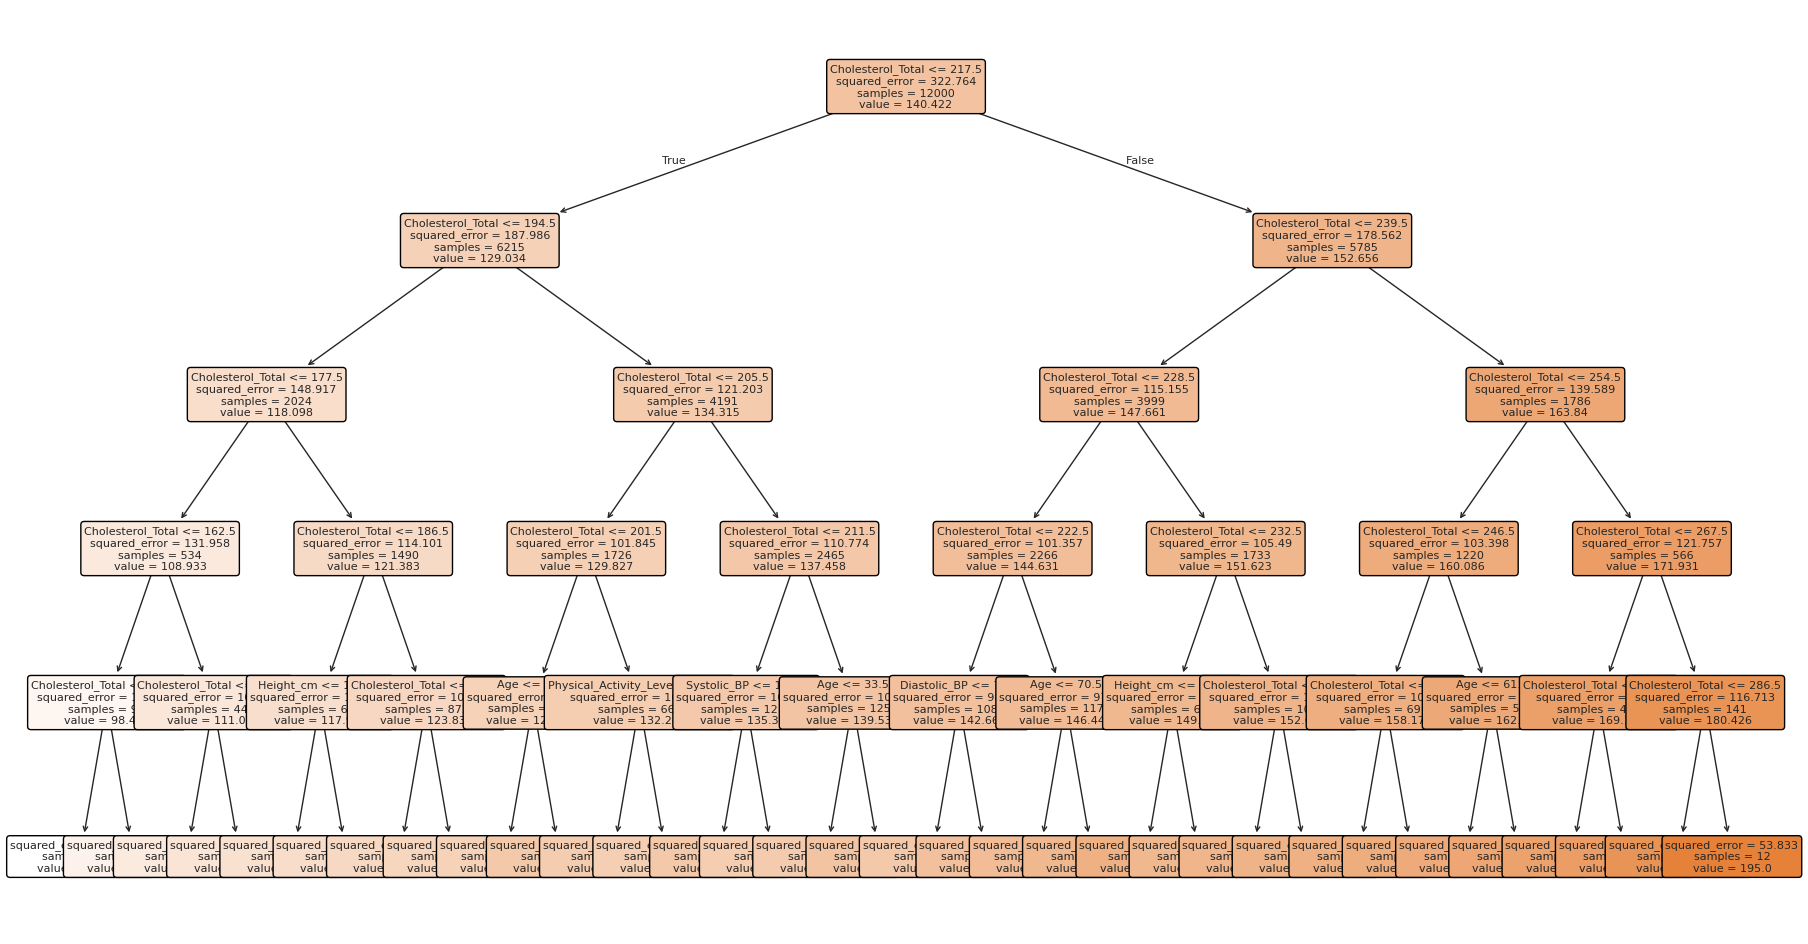

In [24]:
best_tree_reg = tree_reg.best_estimator_

plt.figure(figsize=(22, 12))
plot_tree(
    best_tree_reg,
    feature_names=X_train_reg.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.show()


## 15. Forêt aléatoire pour `Cholesterol_LDL`

### Justification du choix

Comme en classification, la forêt aléatoire permet souvent d'améliorer un arbre unique en réduisant la variance.


In [25]:
param_rf_reg = [{
    'n_estimators': [200],
    'max_features': ['sqrt', 5],
    'max_depth': [None, 8, 12],
    'min_samples_leaf': [1, 5],
}]

rf_reg, y_pred_rf_reg, res_rf_reg = resume_regression(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_rf_reg,
    X_train_reg,
    Y_train_reg,
    X_test_reg,
    Y_test_reg,
    'Foret aleatoire',
)

print("Meilleur score CV =", -rf_reg.best_score_)
print("Meilleurs paramètres =", rf_reg.best_params_)
res_rf_reg


Meilleur score CV = 10.368375977749917
Meilleurs paramètres = {'max_depth': 12, 'max_features': 5, 'min_samples_leaf': 1, 'n_estimators': 200}


,Modele,Best params,CV RMSE,Test RMSE,Test MAE,Test R2
0,Foret aleatoire,"{'max_depth': 12, 'max_features': 5, 'min_samp...",10.368376,10.128531,7.989841,0.672583


In [26]:
importances_rf_reg = pd.Series(
    rf_reg.best_estimator_.feature_importances_,
    index=X_train_reg.columns,
).sort_values(ascending=False)

importances_rf_reg.head(10)


Cholesterol_Total      0.714808
Age                    0.078456
BMI                    0.030462
Weight_kg              0.027999
Systolic_BP            0.025109
Height_cm              0.023036
Fasting_Blood_Sugar    0.020939
Diastolic_BP           0.019703
Cholesterol_HDL        0.017877
Stress_Level           0.011975
dtype: float64

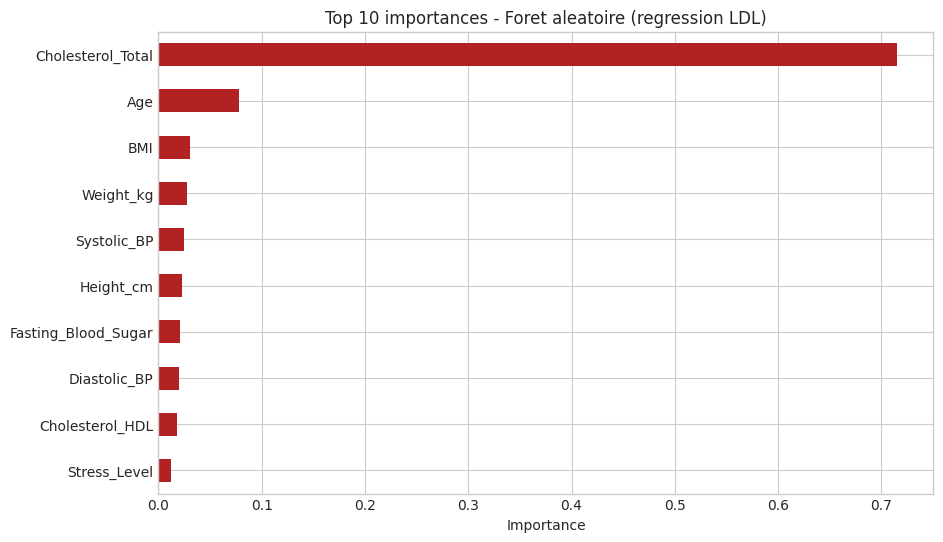

In [27]:
plt.figure(figsize=(10, 6))
importances_rf_reg.head(10).sort_values().plot(kind='barh', color='firebrick')
plt.title('Top 10 importances - Foret aleatoire (regression LDL)')
plt.xlabel('Importance')
plt.show()


## 16. Boosting pour `Cholesterol_LDL`

### Justification du choix

Le boosting est souvent très efficace sur les données tabulaires de régression, car il ajuste progressivement les erreurs résiduelles.


In [28]:
param_gb_reg = [{'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [1, 2, 3]}]

gb_reg, y_pred_gb_reg, res_gb_reg = resume_regression(
    GradientBoostingRegressor(random_state=42),
    param_gb_reg,
    X_train_reg,
    Y_train_reg,
    X_test_reg,
    Y_test_reg,
    'Boosting',
)

print("Meilleur score CV =", -gb_reg.best_score_)
print("Meilleurs paramètres =", gb_reg.best_params_)
res_gb_reg


Meilleur score CV = 10.098540995906669
Meilleurs paramètres = {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 200}


,Modele,Best params,CV RMSE,Test RMSE,Test MAE,Test R2
0,Boosting,"{'learning_rate': 0.1, 'max_depth': 1, 'n_esti...",10.098541,9.829416,7.763037,0.691636


## 17. Tableau récapitulatif en régression

On réunit les performances des quatre méthodes sur l'échantillon test.


In [29]:
resume_reg = pd.concat(
    [res_svr_reg, res_tree_reg, res_rf_reg, res_gb_reg],
    ignore_index=True,
)

resume_reg = resume_reg.sort_values('Test RMSE')
resume_reg


,Modele,Best params,CV RMSE,Test RMSE,Test MAE,Test R2
3,Boosting,"{'learning_rate': 0.1, 'max_depth': 1, 'n_esti...",10.098541,9.829416,7.763037,0.691636
1,Arbre de regression,"{'ccp_alpha': 0, 'max_depth': 5, 'min_samples_...",10.159871,9.891349,7.804877,0.687738
2,Foret aleatoire,"{'max_depth': 12, 'max_features': 5, 'min_samp...",10.368376,10.128531,7.989841,0.672583
0,SVR (rbf),"{'C': 5, 'epsilon': 1.0, 'gamma': 0.05, 'kerne...",10.468102,10.240508,8.109381,0.665303


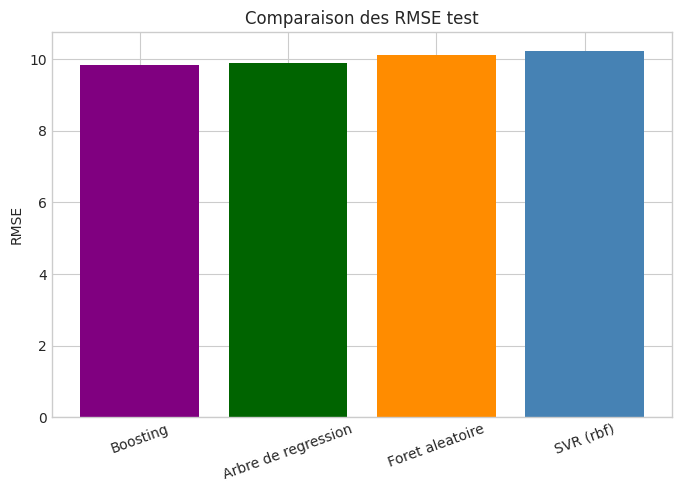

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(resume_reg['Modele'], resume_reg['Test RMSE'], color=['purple', 'darkgreen', 'darkorange', 'steelblue'])
plt.title('Comparaison des RMSE test')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.show()


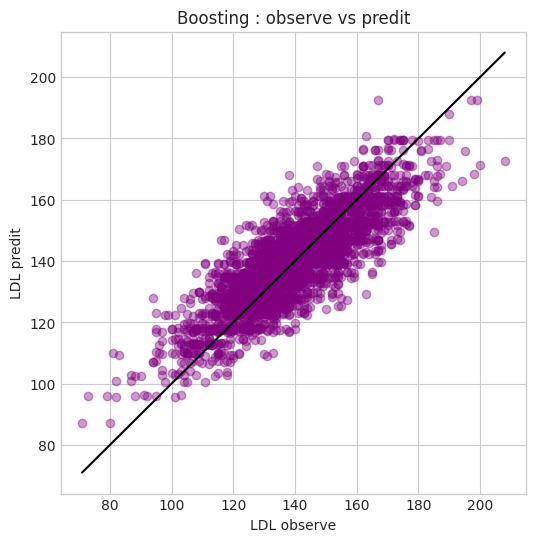

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test_reg, y_pred_gb_reg, alpha=0.4, color='purple')
plt.plot([Y_test_reg.min(), Y_test_reg.max()], [Y_test_reg.min(), Y_test_reg.max()], color='black')
plt.xlabel('LDL observe')
plt.ylabel('LDL predit')
plt.title('Boosting : observe vs predit')
plt.show()


## 18. Interprétation des résultats en régression

Avec `random_state=42`, on obtient les résultats suivants :

- `Boosting` : `RMSE test = 9.8294`, `R2 = 0.6916`
- `Arbre de régression` : `RMSE test = 9.8913`, `R2 = 0.6877`
- `Forêt aléatoire` : `RMSE test = 10.1285`, `R2 = 0.6726`
- `SVR (rbf)` : `RMSE test = 10.2405`, `R2 = 0.6653`

Commentaires :

- Le meilleur modèle est ici le `boosting`, avec le plus petit `RMSE` et le plus grand `R2`.
- L'arbre de régression seul donne déjà un très bon résultat, ce qui montre qu'il existe probablement des effets de seuil assez nets dans les données synthétiques.
- La forêt aléatoire est correcte mais, sur cette grille simple, elle n'améliore pas l'arbre seul.
- Le `SVR` fonctionne correctement, mais il reste un peu derrière les méthodes basées sur les arbres.

En termes d'amélioration :

- le `boosting` améliore le `RMSE` d'environ `0.41` point par rapport au `SVR`,
- il améliore aussi légèrement le `R2` (`0.6916` contre `0.6653`),
- l'amélioration face à l'arbre seul existe mais elle reste modérée, ce qui est une information intéressante : ici, un modèle relativement simple reste déjà compétitif.


## 19. Conclusion générale

### Pour `Heart_Disease_Risk`

Les meilleurs modèles sont très proches :
- `SVM (rbf)` est légèrement premier sur l'accuracy test,
- `boosting` est très compétitif et a le meilleur `F1-score`,
- `forêt aléatoire` est un très bon compromis si l'on veut aussi interpréter les importances.

### Pour `Cholesterol_LDL`

Le `boosting` est le meilleur des quatre modèles testés, juste devant l'arbre de régression.

### Retour méthodologique

Les modèles non linéaires semblent adaptés ici :
- ils captent mieux les effets de seuil et les interactions,
- les méthodes d'ensemble sont globalement plus performantes qu'un arbre isolé,
- la différence entre modèles reste cependant raisonnable, ce qui montre qu'il ne faut pas compliquer inutilement le code.

Ce notebook reste donc volontairement simple, mais il couvre bien la consigne :
- justification des choix,
- identification des hyperparamètres,
- réglage par validation croisée,
- comparaison sur l'échantillon test,
- interprétation des résultats pour les deux variables à prédire.
